# Healthcare Disease Prediction — Duplicate & Irrelevant Column Analysis

## Objective

The objective of this notebook is to identify duplicate records and evaluate whether any columns may be irrelevant or unsuitable for disease prediction.

This notebook focuses on analysis and documentation. Final column removal and data cleaning will be performed in the appropriate cleaning/preprocessing stage.


In [ ]:
# Import required libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Libraries imported successfully.")


Libraries imported successfully.


## 1. Load the Dataset

The dataset is loaded directly from the Team-6 GitHub repository.


In [ ]:
# GitHub raw dataset URL

url = "https://raw.githubusercontent.com/vyasanbmathew2008/Team-6/main/healthcare-disease-prediction/dataset/healthcare_dataset.csv"

# Load dataset
df = pd.read_csv(url)

print("Dataset loaded successfully!")
print(f"Dataset shape: {df.shape}")


Dataset loaded successfully!
Dataset shape: (55500, 15)


In [ ]:
# Display the first 5 records

df.head()


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
0,Bobby JacksOn,30,Male,B-,Cancer,2024-01-31,Matthew Smith,Sons and Miller,Blue Cross,18856.281306,328,Urgent,2024-02-02,Paracetamol,Normal
1,LesLie TErRy,62,Male,A+,Obesity,2019-08-20,Samantha Davies,Kim Inc,Medicare,33643.327287,265,Emergency,2019-08-26,Ibuprofen,Inconclusive
2,DaNnY sMitH,76,Female,A-,Obesity,2022-09-22,Tiffany Mitchell,Cook PLC,Aetna,27955.096079,205,Emergency,2022-10-07,Aspirin,Normal
3,andrEw waTtS,28,Female,O+,Diabetes,2020-11-18,Kevin Wells,"Hernandez Rogers and Vang,",Medicare,37909.782410,450,Elective,2020-12-18,Ibuprofen,Abnormal
4,adrIENNE bEll,43,Female,AB+,Cancer,2022-09-19,Kathleen Hanna,White-White,Aetna,14238.317814,458,Urgent,2022-10-09,Penicillin,Abnormal


## 2. Check Duplicate Records

Duplicate records can cause problems during model training because the same observation may appear more than once.

We first check for exact duplicate rows across all columns.


In [ ]:
# Count exact duplicate rows

duplicate_count = df.duplicated().sum()

print(f"Number of exact duplicate rows: {duplicate_count}")


Number of exact duplicate rows: 534


In [ ]:
# Calculate duplicate percentage

duplicate_percentage = (duplicate_count / len(df)) * 100

print(f"Percentage of duplicate rows: {duplicate_percentage:.2f}%")


Percentage of duplicate rows: 0.96%


## 3. Inspect Duplicate Records

If duplicate records are present, we display all copies of those records for further inspection.


In [ ]:
# Display duplicate records

if duplicate_count > 0:
    duplicate_rows = df[df.duplicated(keep=False)]
    display(duplicate_rows)
else:
    print("No exact duplicate records were found.")


,Name,Age,Gender,Blood Type,Medical Condition,Date of Admission,Doctor,Hospital,Insurance Provider,Billing Amount,Room Number,Admission Type,Discharge Date,Medication,Test Results
64,Nancy glOVeR,58,Male,A-,Hypertension,2020-05-08,Jennifer Larson,"Khan, and Rodriguez Fischer",Medicare,19183.168885,378,Emergency,2020-06-01,Aspirin,Abnormal
107,DAVid higgInS,49,Female,B-,Arthritis,2021-03-05,Erin Henderson MD,"Evans and Hall Schneider,",Medicare,24948.477824,361,Emergency,2021-03-20,Penicillin,Abnormal
148,RoBErt hIGGInS,42,Male,AB-,Asthma,2021-05-06,Scott Davis,"and Ford Lee, Rodriguez",Medicare,13355.782085,451,Elective,2021-05-29,Ibuprofen,Inconclusive
154,kevIn HiCKs,66,Male,AB+,Arthritis,2021-06-23,Kelly Murphy,Robinson Inc,Medicare,1897.891727,196,Elective,2021-07-09,Ibuprofen,Abnormal
159,miCHAeL TayloR,29,Male,O-,Asthma,2020-02-27,Erica Mccormick,Donaldson-Frey,Medicare,41939.119937,453,Elective,2020-03-26,Ibuprofen,Normal
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
55461,connOR coMPTon,63,Male,A+,Asthma,2021-08-21,Jonathan Allen,"and Willis Mullins, Bowers",Medicare,1936.702824,375,Emergency,2021-09-16,Paracetamol,Normal
55462,alYSsA mIlLER,35,Female,A-,Diabetes,2022-06-30,Ryan Price,Shelton-Gallagher,UnitedHealthcare,2210.460898,289,Elective,2022-07-27,Penicillin,Normal
55464,ChRIs huGHeS,35,Female,AB-,Obesity,2024-02-28,Katelyn Perry,Lyons-Hansen,Blue Cross,11889.154513,128,Emergency,2024-03-14,Paracetamol,Abnormal
55484,keNNEtH alvarez,80,Male,O+,Cancer,2022-05-05,Andrew Conner,Sons Mayo and,Cigna,45653.802310,114,Elective,2022-05-17,Aspirin,Normal


## 4. Check Repeated Patient Names

Repeated names do not automatically mean duplicate records. A patient may have multiple admissions.

Therefore, repeated names are inspected only for analysis and are not automatically removed.


In [ ]:
# Check repeated patient names

if "Name" in df.columns:
    repeated_names = df["Name"].value_counts()
    repeated_names = repeated_names[repeated_names > 1]

    print(f"Number of names appearing more than once: {len(repeated_names)}")
    display(repeated_names.head(20).to_frame("Record Count"))
else:
    print("Name column not found.")


Number of names appearing more than once: 5507


,Record Count
Name,
DAvId muNoZ,3
Cody BurNett,2
roDNEy Shaw,2
grEGorY smitH,2
MelisSA coOk,2
MiCHael LeE,2
pETEr bakER,2
TInA THompsoN,2
mrS. gabRieLa piTTmAn,2


## 5. Identify Potentially Irrelevant Columns

A feature should not be removed simply because it has many unique values.

Each column should be evaluated based on:

- Its relevance to disease prediction
- Whether it represents an identifier
- Whether it contains useful predictive information
- Whether it creates unnecessary complexity
- Whether it could introduce data leakage


In [ ]:
# Display columns, data types, and number of unique values

column_analysis = pd.DataFrame({
    "Column": df.columns,
    "Data Type": df.dtypes.astype(str).values,
    "Unique Values": [df[column].nunique(dropna=True) for column in df.columns],
    "Unique Percentage": [
        (df[column].nunique(dropna=True) / len(df)) * 100
        for column in df.columns
    ]
})

column_analysis


,Column,Data Type,Unique Values,Unique Percentage
0,Name,object,49992,90.075676
1,Age,int64,77,0.138739
2,Gender,object,2,0.003604
3,Blood Type,object,8,0.014414
4,Medical Condition,object,6,0.010811
5,Date of Admission,object,1827,3.291892
6,Doctor,object,40341,72.686486
7,Hospital,object,39876,71.848649
8,Insurance Provider,object,5,0.009009
9,Billing Amount,float64,50000,90.090090


## 6. Initial Feature Relevance Review

| Column | Initial Assessment | Reason |
|---|---|---|
| Name | Potentially irrelevant | Identifies a person and is high-cardinality; unlikely to provide generalizable disease information. |
| Age | Relevant | Demographic information that may be predictive of disease. |
| Gender | Potentially relevant | Demographic feature that may contain predictive information. |
| Blood Type | Potentially relevant | Can be investigated as a possible predictor. |
| Medical Condition | Target | The disease/condition to be predicted. |
| Date of Admission | Potentially relevant | Can be transformed into useful time-based features if justified. |
| Doctor | Potentially irrelevant/high-cardinality | May identify individual doctors rather than patient characteristics. |
| Hospital | Potentially irrelevant/high-cardinality | May capture institution-specific patterns rather than generalizable patient information. |
| Insurance Provider | Potentially relevant | Can be investigated as a categorical feature. |
| Billing Amount | Potentially relevant | Numerical feature that may contain useful information, subject to domain/leakage considerations. |
| Room Number | Potentially irrelevant | Usually represents a location/administrative identifier rather than patient health information. |
| Admission Type | Potentially relevant | May contain useful information about the nature of admission. |
| Discharge Date | Potentially relevant | Can potentially be transformed into length of stay, but may cause leakage depending on prediction timing. |
| Medication | Potentially relevant | May contain information associated with the condition, depending on when prediction is made. |
| Test Results | Potentially relevant | May contain useful predictive information, depending on when results are available. |

> These are initial assessments, not final removal decisions. The team should confirm the prediction scenario before removing features.


## 7. Check the Target Variable

`Medical Condition` is the target variable for this project.

We inspect its categories and distribution to confirm the disease classes present in the dataset.


In [ ]:
# Check target variable

target_column = "Medical Condition"

if target_column in df.columns:
    print("Target variable:", target_column)
    print("\nTarget categories:")
    print(df[target_column].unique())
else:
    print(f"Target column '{target_column}' was not found.")


Target variable: Medical Condition

Target categories:
['Cancer' 'Obesity' 'Diabetes' 'Asthma' 'Hypertension' 'Arthritis']


In [ ]:
# Target class distribution

if target_column in df.columns:
    target_counts = df[target_column].value_counts()
    target_percentages = df[target_column].value_counts(normalize=True) * 100

    target_summary = pd.DataFrame({
        "Count": target_counts,
        "Percentage": target_percentages.round(2)
    })

    display(target_summary)


,Count,Percentage
Medical Condition,,
Arthritis,9308,16.77
Diabetes,9304,16.76
Hypertension,9245,16.66
Obesity,9231,16.63
Cancer,9227,16.63
Asthma,9185,16.55


## 8. Visualize Target Distribution

A bar chart is used to understand the distribution of the disease classes.


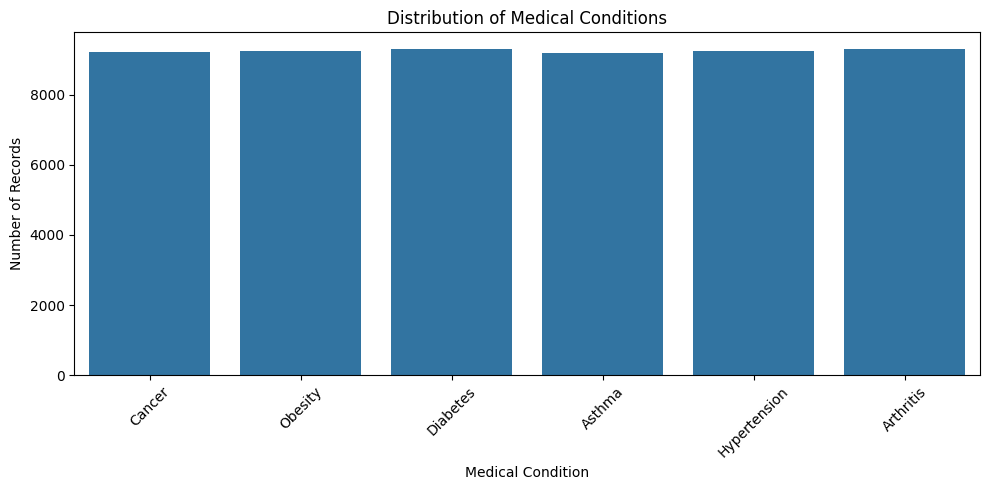

In [ ]:
# Plot target distribution

if target_column in df.columns:
    plt.figure(figsize=(10, 5))
    sns.countplot(data=df, x=target_column)
    plt.title("Distribution of Medical Conditions")
    plt.xlabel("Medical Condition")
    plt.ylabel("Number of Records")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()


## 9. Duplicate and Irrelevant Column Summary


In [ ]:
# Generate analysis summary

print("DUPLICATE & IRRELEVANT COLUMN ANALYSIS")
print("=" * 55)
print(f"Total records            : {len(df)}")
print(f"Total columns            : {len(df.columns)}")
print(f"Exact duplicate records  : {duplicate_count}")
print(f"Duplicate percentage     : {duplicate_percentage:.2f}%")
print(f"Target variable          : {target_column}")

if target_column in df.columns:
    print(f"Number of target classes : {df[target_column].nunique()}")


DUPLICATE & IRRELEVANT COLUMN ANALYSIS
Total records            : 55500
Total columns            : 15
Exact duplicate records  : 534
Duplicate percentage     : 0.96%
Target variable          : Medical Condition
Number of target classes : 6
